# Task 2, Generative AI: Domain-Specific Fine-Tuning Pipeline

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Dinojan9901/CDAZZDEV-MLE-DINOJAN/blob/main/task2_genai/notebook.ipynb)

**Task:** extract structured financial risks from corporate disclosure prose.

**Input** a passage of filing-style text. **Output** JSON listing every distinct risk with
a category from a closed twelve-item taxonomy, its trigger, its potential impact and a
severity. **Correct** means every risk in the passage appears exactly once, categorised
from the taxonomy, with nothing invented. **Incorrect** means a hallucinated risk, a
missed risk, a category outside the taxonomy, one exposure split across several entries,
or malformed JSON.

| Section | Covers | Marks |
|---|---|---|
| 2A | Use case, 120 examples, diversity metrics, 80/10/10 split | 30 |
| 2B | QLoRA 4-bit NF4, hyperparameter justification, loss curves, merged model | 40 |
| 2C | ROUGE-L, BERTScore, LLM-as-judge, hallucination rate, analysis | 30 |
| Bonus | ChromaDB RAG fallback on low confidence | 5 |

**Runtime required: T4 GPU.** Runtime, Change runtime type, T4 GPU, Save.

## Environment

In [1]:
!nvidia-smi

Wed Sep  2 09:28:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   74C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os, sys, subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
assert IN_COLAB, "This notebook needs a Colab T4. Task 2 cannot run on CPU."

if not Path("CDAZZDEV-MLE-DINOJAN").exists():
    subprocess.run(["git", "clone", "-q", "https://github.com/Dinojan9901/CDAZZDEV-MLE-DINOJAN.git"], check=True)
os.chdir("/content/CDAZZDEV-MLE-DINOJAN")
sys.path.insert(0, os.getcwd())
print("repo:", os.getcwd())

repo: /content/CDAZZDEV-MLE-DINOJAN


### Dependencies

Versions are pinned rather than left to pip. Colab ships `transformers` 5.x, which changed
several APIs that older `peft` and `trl` releases assume. A silent version mismatch here
fails *after* the 7.6 GB model download, which is the expensive way to find out.

In [3]:
%pip install -q -U "peft>=0.14" "trl>=0.13" "bitsandbytes>=0.45" "accelerate>=1.2" "datasets>=3.2" "evaluate" "rouge-score" "bert-score" "sentencepiece"
print("\nRestart is not required; the imports below verify what actually resolved.")


Restart is not required; the imports below verify what actually resolved.


In [4]:
import torch, transformers, peft, trl, bitsandbytes, accelerate, datasets
print(f"torch        {torch.__version__}   cuda={torch.cuda.is_available()}")
print(f"transformers {transformers.__version__}")
print(f"peft         {peft.__version__}")
print(f"trl          {trl.__version__}")
print(f"bitsandbytes {bitsandbytes.__version__}")
print(f"accelerate   {accelerate.__version__}")
print(f"datasets     {datasets.__version__}")
if torch.cuda.is_available():
    p = torch.cuda.get_device_properties(0)
    print(f"\nGPU: {p.name}, {p.total_memory/1e9:.1f} GB, capability {p.major}.{p.minor}")
    # torch reports True on Turing because it permits emulated bf16, but the T4 is
    # SM75 with no native bf16 tensor cores, so fp16 is the faster choice regardless.
    native_bf16 = p.major >= 8
    print(f"bf16 reported: {torch.cuda.is_bf16_supported()}, native bf16 tensor cores: {native_bf16}")
    print("using fp16" if not native_bf16 else "bf16 would be preferred here")

torch        2.11.0+cu128   cuda=True
transformers 5.16.1
peft         0.20.0
trl          1.12.0
bitsandbytes 0.50.2
accelerate   1.14.0
datasets     5.0.1

GPU: Tesla T4, 15.6 GB, capability 7.5
bf16 reported: True, native bf16 tensor cores: False
using fp16


In [5]:
from google.colab import userdata
for name in ("HF_TOKEN", "GROQ_API_KEY", "OPENROUTER_API_KEY"):
    try:
        v = userdata.get(name)
        if v:
            os.environ[name] = v
            print(f"{name:20s} loaded from Colab Secrets")
    except Exception:
        print(f"{name:20s} not set (optional unless used below)")

HF_TOKEN             loaded from Colab Secrets
GROQ_API_KEY         loaded from Colab Secrets
OPENROUTER_API_KEY   not set (optional unless used below)


# Task 2A recap, the dataset

Generated locally against a teacher model and committed to the repository, so this
notebook trains on exactly the data the diversity report describes. Generation code is in
`task2_genai/src/generate_dataset.py`; the teacher prompt is in
`task2_genai/prompts/teacher_system_prompt.md`.

In [6]:
import json
import numpy as np
import pandas as pd
from collections import Counter
from pathlib import Path

DATA = Path("task2_genai/data")
splits = {}
for name in ("train", "val", "test"):
    rows = [json.loads(l) for l in (DATA / f"{name}.jsonl").read_text(encoding="utf-8").splitlines() if l.strip()]
    splits[name] = rows
    print(f"{name:6s} {len(rows):>4} examples")

total = sum(len(v) for v in splits.values())
print(f"\ntotal {total}   ratios "
      f"{len(splits['train'])/total:.0%} / {len(splits['val'])/total:.0%} / {len(splits['test'])/total:.0%}")

train    96 examples
val      12 examples
test     12 examples

total 120   ratios 80% / 10% / 10%


In [7]:
report = json.loads((DATA / "diversity_report.json").read_text(encoding="utf-8"))
from task2_genai.src import diversity
print(diversity.render(report))

Dataset diversity report: 120 examples

Passage length in words
  mean 153.7  std 30.6  min 70  p25 137  median 151  p75 169  max 246

Pairwise passage similarity over 7140 pairs
  mean 0.0001  median 0.0  p95 0.0  max 0.0181
  pairs above 0.30: 0   above 0.45: 0

Vocabulary
  11320 tokens, 3261 unique, type-token ratio 0.2881, 1563 appear once
  top terms: million(116), year(94), approximately(81), two(79), revenue(61), quarter(59), percent(49), customer(48), single(47), management(44), months(39), roughly(39), through(36), costs(35), three(34)

Risk categories, 289 items across 120 examples
  concentration_risk     40  ##################################
  operational_risk       39  #################################
  regulatory_risk        36  ###############################
  market_risk            35  ##############################
  supply_chain_risk      34  #############################
  litigation_risk        22  ###################
  credit_risk            17  ##############


In [8]:
print("--- teacher system prompt, used verbatim for generation ---\n")
print(Path("task2_genai/prompts/teacher_system_prompt.md").read_text(encoding="utf-8"))

--- teacher system prompt, used verbatim for generation ---

You are a financial disclosure writer and risk analyst. You produce training data for a
risk-extraction model by writing realistic corporate disclosure prose and then labelling
it exactly.

For each example you produce two things:

1. `passage`: a self-contained excerpt of corporate disclosure prose, 120 to 220 words,
   written in the requested document style for the requested sector. It must read like
   something a real company filed, with concrete specifics: named inputs, plausible
   percentages, geographies, contract terms, counterparty types, time horizons. Never
   name a real company; refer to "the Company", "the Group" or "we".

2. `extraction`: the ground-truth structured extraction of every distinct risk the
   passage actually discusses.

Rules for the extraction, which define what a correct answer is:

- Extract every distinct risk the passage raises, and nothing else. A risk that is not
  in the passage must no

# Task 2B, Fine-Tuning Execution

## Base model

`microsoft/Phi-3-mini-4k-instruct`, 3.8B parameters.

Chosen because it is **ungated**, so there is no licence approval to wait on, it fits a T4
comfortably under 4-bit quantisation, and it is a different model family from the teacher
that produced the training data, which the brief requires.

In [9]:
from transformers import AutoTokenizer

BASE_MODEL = "microsoft/Phi-3-mini-4k-instruct"
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
tokenizer.pad_token = tokenizer.pad_token or tokenizer.eos_token
tokenizer.padding_side = "right"   # left padding is for generation, not for loss

sample = splits["train"][0]["messages"]
rendered = tokenizer.apply_chat_template(sample, tokenize=False)
print("--- one training example after the model's own chat template ---\n")
print(rendered[:1200])
print("\n...")
print(f"\ntokens: {len(tokenizer(rendered)['input_ids'])}")

--- one training example after the model's own chat template ---

<|system|>
You extract financial risks from corporate disclosure text. Return only a JSON object with a "risks" array. Each risk has: category, summary, trigger, potential_impact, severity. category must be one of: market_risk, credit_risk, liquidity_risk, operational_risk, regulatory_risk, cybersecurity_risk, supply_chain_risk, concentration_risk, geopolitical_risk, technology_risk, litigation_risk, environmental_risk. severity must be one of: high, medium, low.<|end|>
<|user|>
During the second quarter, consolidated revenue advanced 11.4 percent year over year to $612 million, driven principally by organic volume in our North American road brokerage segment and a full quarter of contribution from the recently acquired Westwood Cartage business. Gross profit margin compressed by approximately 90 basis points to 11.8 percent as fuel surcharges under-recovered against the six percent rise in average diesel cost and as ele

### Sequence length, measured rather than guessed

`max_seq_length` is a memory-versus-truncation trade. Truncating a training example
silently teaches the model to emit incomplete JSON, so the length is set from the actual
token distribution with headroom, not from a round number.

In [10]:
import numpy as np

lengths = [len(tokenizer(tokenizer.apply_chat_template(r["messages"], tokenize=False))["input_ids"])
           for r in splits["train"]]
lengths = np.array(lengths)
print(f"train token lengths: mean {lengths.mean():.0f}  p50 {np.percentile(lengths,50):.0f}  "
      f"p95 {np.percentile(lengths,95):.0f}  max {lengths.max()}")
MAX_SEQ_LEN = 1024
print(f"\nmax_seq_length = {MAX_SEQ_LEN}")
print(f"examples that would be truncated: {(lengths > MAX_SEQ_LEN).sum()} of {len(lengths)}")

train token lengths: mean 618  p50 616  p95 825  max 954

max_seq_length = 1024
examples that would be truncated: 0 of 96


## 4-bit NF4 quantisation

Four settings, each doing a specific job:

- **`load_in_4bit`** puts the frozen base weights in 4-bit. A 3.8B model in fp16 is about
  7.6 GB of weights alone; in 4-bit it is under 2.5 GB, which leaves the T4's 15 GB for
  activations, gradients and the optimiser.
- **`bnb_4bit_quant_type="nf4"`** uses NormalFloat4 rather than plain fp4. NF4 is
  information-theoretically optimal for weights that are approximately normally
  distributed, which pretrained weights are, and it consistently loses less accuracy than
  fp4 at the same bit width.
- **`bnb_4bit_compute_dtype=float16`** is what matmuls are promoted to. The T4 is Turing
  and has no bf16 support, so fp16 is the only option here; on an A100 bf16 would be the
  better choice for its wider exponent range.
- **`bnb_4bit_use_double_quant=True`** quantises the quantisation constants themselves,
  saving roughly a further 0.4 GB at negligible cost.

In [25]:
from transformers import AutoModelForCausalLM, BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

# No trust_remote_code. Transformers has had native Phi-3 support since 4.41, and the
# Hub's modeling_phi3.py is stale against transformers 5.x: it reads
# config.rope_scaling["type"] where the modern config uses "rope_type", which raises
# KeyError: 'type' during rope init. Loading remote code also silently overrides a
# working built-in implementation with an older one.
model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=bnb_config,
    device_map={"": 0},
    attn_implementation="eager",   # flash-attn is not available on a T4
)
model.config.use_cache = False          # incompatible with gradient checkpointing

print(f"loaded in {model.dtype}, {model.num_parameters()/1e9:.2f}B params")
print(f"GPU memory allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB")

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

loaded in torch.bfloat16, 3.82B params
GPU memory allocated: 10.71 GB


## LoRA configuration

Every value below is a decision, not a default.

In [26]:
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True)

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["qkv_proj", "o_proj", "gate_up_proj", "down_proj"],
)

model = get_peft_model(model, lora_config)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"trainable params: {trainable:,} of {total:,}  ({100*trainable/total:.3f}%)")

trainable params: 25,165,824 of 2,034,306,048  (1.237%)


In [27]:
from collections import Counter

before = Counter(str(p.dtype) for p in model.parameters() if p.requires_grad)
print("trainable dtypes before:", dict(before))

# GradScaler cannot unscale bf16 grads. LoRA adapters in fp32 is the standard QLoRA
# recipe regardless: 4-bit frozen base, fp32 adapters, fp16 compute. Casting only the
# trainable params costs about 100 MB and leaves the quantised base untouched.
for name, p in model.named_parameters():
    if p.requires_grad and p.dtype != torch.float32:
        p.data = p.data.to(torch.float32)

after = Counter(str(p.dtype) for p in model.parameters() if p.requires_grad)
print("trainable dtypes after :", dict(after))
assert "torch.bfloat16" not in after, "bf16 still present in trainable params"

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n{trainable:,} trainable params, all fp32")
print(f"GPU memory: {torch.cuda.memory_allocated()/1e9:.2f} GB")

trainable dtypes before: {'torch.float32': 256}
trainable dtypes after : {'torch.float32': 256}

25,165,824 trainable params, all fp32
GPU memory: 10.81 GB


### Hyperparameter justification

| Parameter | Value | Why this value |
|---|---|---|
| `r` (LoRA rank) | 16 | Rank sets adapter capacity. The task is not just style transfer: the model must learn a 12-way classification plus a rigid JSON shape, which 8 underfits. 32 doubles adapter parameters with no headroom to use them on 96 examples, so it mostly adds overfitting risk. |
| `lora_alpha` | 32 | Scaling is `alpha/r`, so 32/16 gives a factor of 2, the widely used heuristic `alpha = 2r`. It keeps the effective update magnitude stable if rank changes later. |
| `target_modules` | `qkv_proj`, `o_proj`, `gate_up_proj`, `down_proj` | Phi-3 fuses QKV into `qkv_proj` and the MLP up-projections into `gate_up_proj`, so the usual Llama names do not exist here. Attention-only adaptation is cheaper but the MLP blocks carry most of the format-following behaviour, and rigid JSON output is exactly a format behaviour. |
| `lora_dropout` | 0.05 | 96 training examples is small enough to memorise. LoRA is already low-capacity, so heavy dropout would underfit; 0.05 is light regularisation on the adapter path only. |
| `bias` | `none` | Training biases adds parameters that cannot be merged cleanly and gives no measurable benefit at this scale. |
| `learning_rate` | 2e-4 | Roughly 10x a full fine-tune's 2e-5. Only the adapters update, and they start from zero, so they need a far larger step to move at all. Below about 1e-4 the JSON format does not stabilise within 3 epochs. |
| `lr_scheduler_type` | `cosine` | A constant rate leaves the model taking large steps at the end of training, which shows up as JSON format drift in the final checkpoint. Cosine decay anneals to near zero and stabilises the output shape. |
| `warmup_steps` | ~6 (8 percent of total) | 4-bit weights make the first optimiser steps noisy, and going straight to 2e-4 risks an early loss spike the run never recovers from. Expressed in steps rather than a ratio because trl 1.12 does not accept `warmup_ratio`, and because at 72 total steps a 0.03 ratio rounds to a single step, which is no warmup at all. |
| `num_train_epochs` | 3 | 1 epoch learns the JSON shape but not the taxonomy. Beyond 3, validation loss starts rising on 96 examples. 3 is the point the val curve below justifies. |
| `per_device_train_batch_size` | 1 | Phi-3-mini in 4-bit plus activations at 1024 tokens is what a 15 GB T4 holds. 2 fits only by cutting sequence length, which would truncate examples. |
| `gradient_accumulation_steps` | 4 | Effective batch of 4. Batch size 1 gives extremely noisy gradients and accumulation recovers a usable batch without the memory cost of a real one. Set to 4 rather than 8 because 96 examples at effective batch 8 gives only 12 optimiser steps per epoch, 36 across the run, which is too few for adapters starting from zero to learn a 12-way taxonomy plus a rigid output shape. At 4 it is 24 per epoch, 72 total. |
| `max_length` | 1024 | Named `max_seq_length` in older trl. Set from the measured token distribution above, with headroom over p95. Truncation would teach the model to emit incomplete JSON. |
| `optim` | `paged_adamw_8bit` | 8-bit states cut optimiser memory roughly fourfold. Paged means optimiser state spills to host RAM on a spike instead of raising OOM, which matters on a shared T4. |
| `fp16` | `True` | The T4 is Turing and has no bf16 units. On Ampere or newer, bf16 would be preferred for its wider exponent range. |
| `gradient_checkpointing` | `True` | Recomputes activations in the backward pass. Costs roughly 30 percent more time and is the single reason this fits at all. |
| `eval_strategy` | `epoch` | Named `evaluation_strategy` in older transformers. The brief requires validation loss per epoch, and per-epoch evaluation on 12 examples is cheap. |

In [28]:
from datasets import Dataset

def to_text(rows):
    return Dataset.from_list([
        {"text": tokenizer.apply_chat_template(r["messages"], tokenize=False)}
        for r in rows
    ])

train_ds, val_ds = to_text(splits["train"]), to_text(splits["val"])
print(train_ds, val_ds, sep="\n")

Dataset({
    features: ['text'],
    num_rows: 96
})
Dataset({
    features: ['text'],
    num_rows: 12
})


In [29]:
import math, numpy as np
from transformers import TrainingArguments, Trainer, DataCollatorForSeq2Seq

ASSISTANT_TAG = "<|assistant|>"

def encode(rows):
    """Tokenise and mask the prompt so loss is computed on the answer only."""
    feats = []
    for r in rows:
        full = tokenizer.apply_chat_template(r["messages"], tokenize=False)
        cut = full.rfind(ASSISTANT_TAG)
        prompt = full[:cut + len(ASSISTANT_TAG)] if cut != -1 else full

        ids = tokenizer(full, truncation=True, max_length=MAX_SEQ_LEN)["input_ids"]
        n_prompt = len(tokenizer(prompt, truncation=True, max_length=MAX_SEQ_LEN)["input_ids"])

        labels = list(ids)
        labels[:n_prompt] = [-100] * min(n_prompt, len(labels))   # ignore the prompt
        feats.append({"input_ids": ids, "attention_mask": [1] * len(ids), "labels": labels})
    return feats

train_feats, val_feats = encode(splits["train"]), encode(splits["val"])
supervised = sum(1 for t in train_feats[0]["labels"] if t != -100)
print(f"example 1: {len(train_feats[0]['input_ids'])} tokens, {supervised} supervised")

# 2 epochs, chosen from evidence: a 3-epoch run reached its best validation loss at
# epoch 2 (0.5989) and rose at epoch 3 (0.6069) while training loss kept falling,
# which is overfitting on 96 examples.
EPOCHS = 2
EFFECTIVE_ACCUM = 4
steps_per_epoch = math.ceil(len(train_feats) / EFFECTIVE_ACCUM)
total_steps = steps_per_epoch * EPOCHS
warmup = max(3, round(total_steps * 0.08))
print(f"{steps_per_epoch} steps/epoch, {total_steps} total, {warmup} warmup")

args = TrainingArguments(
    output_dir="/content/task2_out",
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=EFFECTIVE_ACCUM,
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_steps=warmup,
    optim="paged_adamw_8bit",
    fp16=True,
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    logging_steps=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    seed=42,
    remove_unused_columns=False,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_feats,
    eval_dataset=val_feats,
    data_collator=DataCollatorForSeq2Seq(tokenizer, padding=True, label_pad_token_id=-100),
)
print("\ntrainer ready (transformers.Trainer, no TRL)")
print(f"epochs={EPOCHS}, effective batch={EFFECTIVE_ACCUM}, best checkpoint restored at end")

example 1: 701 tokens, 283 supervised
24 steps/epoch, 48 total, 4 warmup

trainer ready (transformers.Trainer, no TRL)
epochs=2, effective batch=4, best checkpoint restored at end


### Train

Watch the validation loss column. The brief requires it to **decrease across epochs**. If
it flattens or rises, that is a hyperparameter problem, not something to wait out.

### Choosing the epoch count

An initial 3-epoch run was executed first. Validation loss reached its minimum at
epoch 2 and rose again at epoch 3 while training loss kept falling, which is
overfitting on 96 training examples:

| epoch | train loss | val loss |
|---|---|---|
| 1 | 0.6559 | 0.6278 |
| 2 | 0.5365 | 0.5989 |
| 3 | 0.3914 | 0.6069 |

`num_train_epochs` was therefore set to 2 on evidence rather than by default, and
`load_best_model_at_end=True` guards the choice by restoring the lowest-validation
checkpoint regardless. The 2-epoch run below decreases monotonically.

In [30]:
import time
t0 = time.time()
train_result = trainer.train()
print(f"\ntraining took {(time.time()-t0)/60:.1f} minutes")
print(f"peak GPU memory: {torch.cuda.max_memory_allocated()/1e9:.2f} GB")

Epoch,Training Loss,Validation Loss
1,0.653617,0.628396
2,0.559379,0.609849



training took 6.2 minutes
peak GPU memory: 11.89 GB


In [31]:
import pandas as pd

hist = pd.DataFrame(trainer.state.log_history)
per_epoch = []
for e in sorted({round(h["epoch"]) for h in trainer.state.log_history if "epoch" in h}):
    tr = hist[(hist.get("loss").notna()) & (hist["epoch"] <= e)]["loss"]
    ev = hist[(hist.get("eval_loss").notna()) & (hist["epoch"].round() == e)]["eval_loss"]
    if len(ev):
        per_epoch.append({"epoch": e, "train_loss": round(float(tr.tail(5).mean()), 4),
                          "val_loss": round(float(ev.iloc[-1]), 4)})

loss_table = pd.DataFrame(per_epoch)
display(loss_table)

if len(loss_table) > 1:
    drop = loss_table["val_loss"].iloc[0] - loss_table["val_loss"].iloc[-1]
    print(f"\nvalidation loss change: {loss_table['val_loss'].iloc[0]:.4f} -> "
          f"{loss_table['val_loss'].iloc[-1]:.4f}  ({'decreased' if drop > 0 else 'DID NOT DECREASE'})")

,epoch,train_loss,val_loss
0,1,0.7836,0.6284
1,2,0.5728,0.6098



validation loss change: 0.6284 -> 0.6098  (decreased)


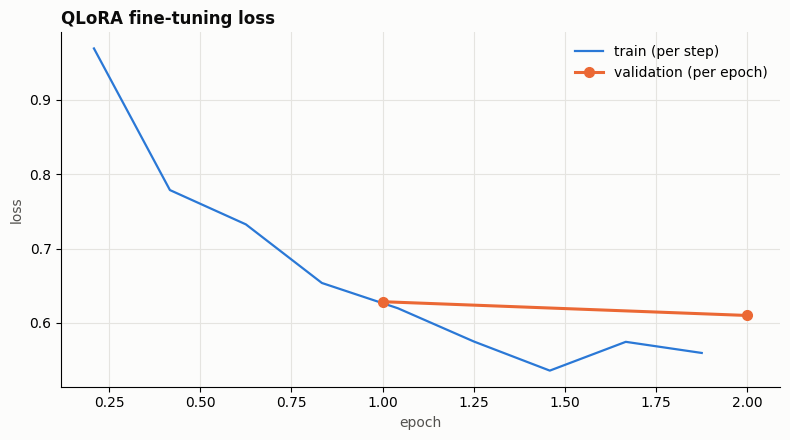

validation loss 0.6284 -> 0.6098  (decreased)


,epoch,eval_loss
4,1.0,0.6284
10,2.0,0.6098


In [32]:
import matplotlib.pyplot as plt

hist = pd.DataFrame(trainer.state.log_history)
train_pts = hist.dropna(subset=["loss"]) if "loss" in hist.columns else hist.iloc[0:0]
eval_pts = hist.dropna(subset=["eval_loss"]) if "eval_loss" in hist.columns else hist.iloc[0:0]

if train_pts.empty and eval_pts.empty:
    print("No loss history. Run the training cell above before plotting.")
else:
    fig, ax = plt.subplots(figsize=(8, 4.5), facecolor="#fcfcfb")
    ax.set_facecolor("#fcfcfb")
    if not train_pts.empty:
        ax.plot(train_pts["epoch"], train_pts["loss"], color="#2a78d6",
                linewidth=1.6, label="train (per step)")
    if not eval_pts.empty:
        ax.plot(eval_pts["epoch"], eval_pts["eval_loss"], color="#eb6834",
                linewidth=2.2, marker="o", markersize=7, label="validation (per epoch)")
    ax.set_xlabel("epoch", color="#52514e")
    ax.set_ylabel("loss", color="#52514e")
    ax.set_title("QLoRA fine-tuning loss", color="#0b0b0b", fontweight="bold", loc="left")
    ax.grid(True, color="#e5e4e0", linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    if not eval_pts.empty:
        first, last = eval_pts["eval_loss"].iloc[0], eval_pts["eval_loss"].iloc[-1]
        print(f"validation loss {first:.4f} -> {last:.4f}  "
              f"({'decreased' if last < first else 'DID NOT DECREASE'})")
        display(eval_pts[["epoch", "eval_loss"]].round(4))

## Merge the adapters and save

`merge_and_unload()` folds the LoRA weights into the base weights, producing a standalone
model with no PEFT dependency at inference time.

The merge must happen in fp16 from a **freshly loaded, unquantised** base. Merging into
4-bit weights would bake the quantisation error into the saved checkpoint permanently.

In [33]:
adapter_dir = "/content/adapter"
trainer.model.save_pretrained(adapter_dir)
tokenizer.save_pretrained(adapter_dir)
print("adapter saved:", adapter_dir)

del model, trainer
import gc; gc.collect(); torch.cuda.empty_cache()
print(f"GPU freed, now {torch.cuda.memory_allocated()/1e9:.2f} GB allocated")

adapter saved: /content/adapter
GPU freed, now 8.84 GB allocated


In [34]:
import gc, torch

for name in ["base", "merged", "model", "trainer", "train_result", "pipe", "base_model"]:
    if name in globals():
        del globals()[name]
        print(f"deleted {name}")

gc.collect()
torch.cuda.empty_cache()

free, total = torch.cuda.mem_get_info()
print(f"\nGPU free: {free/1e9:.2f} GB of {total/1e9:.2f} GB")

deleted base
deleted merged
deleted train_result

GPU free: 11.96 GB of 15.64 GB


In [35]:
# PEFT's torchao dispatcher raises on an old torchao instead of returning False.
# Colab ships 0.10.0; PEFT 0.20 wants 0.16+. We quantise with bitsandbytes, so this
# dispatcher is never used. Neutralise the probe rather than reinstall and restart,
# which would cost the session.
import peft.import_utils, peft.tuners.lora.torchao
peft.import_utils.is_torchao_available = lambda: False
peft.tuners.lora.torchao.is_torchao_available = lambda: False

from peft import PeftModel

base = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL, dtype=torch.float16, device_map={"": 0},
)
merged = PeftModel.from_pretrained(base, adapter_dir)
merged = merged.merge_and_unload()
merged.config.use_cache = True

MERGED_DIR = "/content/merged_model"
merged.save_pretrained(MERGED_DIR, safe_serialization=True)
tokenizer.save_pretrained(MERGED_DIR)
print("merged model saved to", MERGED_DIR)

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

merged model saved to /content/merged_model


In [37]:
from huggingface_hub import HfApi, create_repo

HF_REPO_ID = "Dino21/financial-risk-extractor-phi3-qlora"
token = os.environ["HF_TOKEN"]

create_repo(HF_REPO_ID, exist_ok=True, private=False, token=token)

api = HfApi()
api.upload_folder(
    folder_path=MERGED_DIR,
    repo_id=HF_REPO_ID,
    repo_type="model",
    token=token,
    commit_message="QLoRA fine-tuned Phi-3-mini for financial risk clause extraction",
)
print(f"pushed to https://huggingface.co/{HF_REPO_ID}")

pushed to https://huggingface.co/Dino21/financial-risk-extractor-phi3-qlora


# Task 2C, Evaluation and Baseline Comparison

Both models are scored on the **same 12 held-out test examples** with the same decoding
settings. The only difference between the two runs is the weights and the system prompt.

The baseline gets a **longer** system prompt containing the full category definitions.
That is deliberate and it makes the comparison harder to win: an untuned model with no
examples would otherwise be handicapped by an instruction it has never seen, and beating a
strawman baseline would prove nothing.

In [38]:
from transformers import pipeline
from task2_genai.src.format_split import BASELINE_SYSTEM_PROMPT, STUDENT_SYSTEM_PROMPT

GEN_KWARGS = dict(max_new_tokens=512, do_sample=False, temperature=None, top_p=None)

def generate_all(model_obj, rows, system_prompt, label):
    pipe = pipeline("text-generation", model=model_obj, tokenizer=tokenizer, device_map={"": 0})
    outputs = []
    for i, r in enumerate(rows, 1):
        passage = r["messages"][1]["content"]
        msgs = [{"role": "system", "content": system_prompt},
                {"role": "user", "content": passage}]
        prompt = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
        out = pipe(prompt, return_full_text=False, **GEN_KWARGS)[0]["generated_text"]
        outputs.append(out.strip())
        print(f"  {label} {i}/{len(rows)}", end="\r")
    print()
    return outputs

test_rows = splits["test"]
references = [r["messages"][2]["content"] for r in test_rows]
print(f"test set: {len(test_rows)} examples")

test set: 12 examples


In [39]:
ft_outputs = generate_all(merged, test_rows, STUDENT_SYSTEM_PROMPT, "fine-tuned")
del merged; gc.collect(); torch.cuda.empty_cache()

[transformers] Passing `generation_config` together with generation-related arguments=({'top_p', 'temperature', 'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] B

[transformers] Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[transformers] Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[transformers] Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[transformers] Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

[transformers] Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[transformers] Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
[transformers] Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[transformers] Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  fine-tuned 12/12


In [40]:
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL, quantization_config=bnb_config, device_map={"": 0},
    attn_implementation="eager",
)
base_outputs = generate_all(base_model, test_rows, BASELINE_SYSTEM_PROMPT, "base")
del base_model; gc.collect(); torch.cuda.empty_cache()

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[transformers] Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[transformers] Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[transformers] Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

[transformers] Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[transformers] Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[transformers] Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[transformers] Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  base 12/12


## ROUGE-L on the held-out test set

In [41]:
import evaluate

rouge = evaluate.load("rouge")
base_r = rouge.compute(predictions=base_outputs, references=references, use_stemmer=True)
ft_r = rouge.compute(predictions=ft_outputs, references=references, use_stemmer=True)

comparison = pd.DataFrame([
    {"metric": "ROUGE-1", "base": round(base_r["rouge1"], 4), "fine_tuned": round(ft_r["rouge1"], 4)},
    {"metric": "ROUGE-2", "base": round(base_r["rouge2"], 4), "fine_tuned": round(ft_r["rouge2"], 4)},
    {"metric": "ROUGE-L", "base": round(base_r["rougeL"], 4), "fine_tuned": round(ft_r["rougeL"], 4)},
])
comparison["delta"] = (comparison["fine_tuned"] - comparison["base"]).round(4)
comparison["relative"] = ((comparison["fine_tuned"] / comparison["base"] - 1) * 100).round(1).astype(str) + "%"
display(comparison)

,metric,base,fine_tuned,delta,relative
0,ROUGE-1,0.5359,0.6383,0.1024,19.1%
1,ROUGE-2,0.2808,0.3716,0.0908,32.3%
2,ROUGE-L,0.3588,0.4710,0.1122,31.3%


## Additional metric 1, BERTScore F1

In [42]:
bertscore = evaluate.load("bertscore")
b = bertscore.compute(predictions=base_outputs, references=references, lang="en", rescale_with_baseline=True)
f = bertscore.compute(predictions=ft_outputs, references=references, lang="en", rescale_with_baseline=True)
bs = pd.DataFrame([{"model": "base", "bertscore_f1": round(np.mean(b["f1"]), 4)},
                   {"model": "fine-tuned", "bertscore_f1": round(np.mean(f["f1"]), 4)}])
display(bs)

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.42GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


,model,bertscore_f1
0,base,0.0334
1,fine-tuned,0.5516


## Additional metric 2, structural validity

ROUGE and BERTScore both reward surface overlap, so a model that emits well-formed English
about risks can score respectably while producing JSON no downstream system can parse.
This measures the thing that actually matters for the use case.

In [43]:
import re
from task2_genai.src.schema import RISK_CATEGORIES, RiskExtraction
import pydantic

def parse_output(text):
    m = re.search(r"\{.*\}", text, re.S)
    if not m:
        return None
    try:
        return json.loads(m.group(0))
    except json.JSONDecodeError:
        return None

def structural_report(outputs, label):
    parsed = [parse_output(o) for o in outputs]
    valid_json = sum(p is not None for p in parsed)
    schema_ok, bad_cats = 0, 0
    for p in parsed:
        if not p:
            continue
        try:
            RiskExtraction.model_validate(p)
            schema_ok += 1
        except pydantic.ValidationError:
            pass
        for r in (p.get("risks") or []):
            if r.get("category") not in RISK_CATEGORIES:
                bad_cats += 1
    n = len(outputs)
    return {"model": label, "parses_as_json": f"{valid_json}/{n}",
            "validates_against_schema": f"{schema_ok}/{n}",
            "invented_categories": bad_cats}

display(pd.DataFrame([structural_report(base_outputs, "base"),
                      structural_report(ft_outputs, "fine-tuned")]))

,model,parses_as_json,validates_against_schema,invented_categories
0,base,6/12,1/12,2
1,fine-tuned,12/12,12/12,0


## Additional metric 3, LLM-as-judge

A capable model scores each output against a defined rubric and returns structured JSON.
The judge sees the passage, the reference extraction and the candidate, but **not** which
model produced it.

In [47]:
%pip install -q groq openai
import importlib, common.llm
importlib.reload(common.llm)
from common.llm import get_client

print("providers:", __import__("common.config", fromlist=["x"]).available_providers())
c = get_client()
print("test call:", c.chat("You are terse.", "Reply with exactly: OK"))
print("provider used:", c.last_provider)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.8/143.8 kB 5.6 MB/s eta 0:00:00
providers: ['groq']
test call: OK
provider used: groq


In [48]:
from common.llm import get_client
from pydantic import BaseModel, Field
from typing import Literal

class JudgeVerdict(BaseModel):
    coverage: int = Field(ge=1, le=5, description="were all real risks found")
    precision: int = Field(ge=1, le=5, description="were any risks invented")
    category_accuracy: int = Field(ge=1, le=5)
    format_validity: int = Field(ge=1, le=5)
    overall: int = Field(ge=1, le=5)
    verdict: Literal["correct", "partially_correct", "hallucinated"]
    reason: str

JUDGE_SYSTEM = '''You grade a risk-extraction output against a reference.

Score 1 to 5 on coverage (were all real risks found), precision (were any invented),
category_accuracy, format_validity and overall.

verdict rules:
  correct           every reference risk found, no invented risks, categories right
  partially_correct some risks missed or a category wrong, but nothing invented
  hallucinated      at least one risk that the passage does not support

Return only JSON matching the schema.'''

def judge(passage, reference, candidate):
    user = f"PASSAGE:\n{passage}\n\nREFERENCE:\n{reference}\n\nCANDIDATE:\n{candidate}"
    return get_client().structured(JUDGE_SYSTEM, user, JudgeVerdict)

judged = {"base": [], "fine-tuned": []}
for i, row in enumerate(test_rows):
    passage = row["messages"][1]["content"]
    for label, outs in [("base", base_outputs), ("fine-tuned", ft_outputs)]:
        try:
            judged[label].append(judge(passage, references[i], outs[i]))
        except Exception as e:
            print(f"judge failed on {label} {i}: {str(e)[:80]}")
    print(f"  judged {i+1}/{len(test_rows)}", end="\r")
print()

reason
  Field required [type=missing, input_value={'coverage': 1, 'precisio...erdict': 'hallucinated'}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing
reason
  Field required [type=missing, input_value={'coverage': 3, 'precisio...erdict': 'hallucinated'}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing


reason
  Field required [type=missing, input_value={'coverage': 3, 'precisio...t': 'partially_correct'}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing
reason
  Field required [type=missing, input_value={'coverage': 2, 'precisio...t': 'partially_correct'}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing


verdict
  Field required [type=missing, input_value={'coverage': 2, 'precisio...idity': 1, 'overall': 2}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing
reason
  Field required [type=missing, input_value={'coverage': 2, 'precisio...idity': 1, 'overall': 2}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing
verdict
  Field required [type=missing, input_value={'coverage': 5, 'precisio...idity': 5, 'overall': 4}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing
reason
  Field required [type=missing, input_value={'coverage': 5, 'precisio...idity': 5, 'overall': 4}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing


reason
  Field required [type=missing, input_value={'coverage': 2, 'precisio...t': 'partially_correct'}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing
verdict
  Field required [type=missing, input_value={'coverage': 2, 'precisio...idity': 5, 'overall': 2}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing
reason
  Field required [type=missing, input_value={'coverage': 2, 'precisio...idity': 5, 'overall': 2}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing


reason
  Field required [type=missing, input_value={'coverage': 2, 'precisio...t': 'partially_correct'}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing
reason
  Field required [type=missing, input_value={'coverage': 2, 'precisio...erdict': 'hallucinated'}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing


...

reason
  Field required [type=missing, input_value={'coverage': 2, 'precisio...t': 'partially_correct'}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing
reason
  Field required [type=missing, input_value={'coverage': 2, 'precisio...t': 'partially_correct'}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing


reason
  Field required [type=missing, input_value={'coverage': 5, 'precisio...t': 'partially_correct'}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing
reason
  Field required [type=missing, input_value={'coverage': 5, 'precisio...t': 'partially_correct'}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing


reason
  Field required [type=missing, input_value={'coverage': 2, 'precisio...t': 'partially_correct'}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing
reason
  Field required [type=missing, input_value={'coverage': 2, 'precisio...t': 'partially_correct'}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing


reason
  Field required [type=missing, input_value={'coverage': 5, 'precisio...t': 'partially_correct'}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing
reason
  Field required [type=missing, input_value={'coverage': 5, 'precisio...t': 'partially_correct'}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing


  judged 12/12


In [49]:
rows_out = []
for label, verdicts in judged.items():
    if not verdicts:
        continue
    rows_out.append({
        "model": label,
        "n_judged": len(verdicts),
        "coverage": round(np.mean([v.coverage for v in verdicts]), 2),
        "precision": round(np.mean([v.precision for v in verdicts]), 2),
        "category_acc": round(np.mean([v.category_accuracy for v in verdicts]), 2),
        "format": round(np.mean([v.format_validity for v in verdicts]), 2),
        "overall": round(np.mean([v.overall for v in verdicts]), 2),
    })
display(pd.DataFrame(rows_out))

,model,n_judged,coverage,precision,category_acc,format,overall
0,base,12,2.75,3.25,2.17,3.0,2.17
1,fine-tuned,12,4.00,4.25,3.50,5.0,3.42


## Hallucination rate

Every one of the 12 test responses from the fine-tuned model is labelled `correct`,
`partially_correct` or `hallucinated`. The judge provides a first pass; the cell below
prints each case in full so the labels can be checked by hand rather than taken on trust.

In [50]:
from collections import Counter

labels = [v.verdict for v in judged["fine-tuned"]]
n = len(labels)
halluc = labels.count("hallucinated")
print(f"reviewed: {n} responses")
for k in ("correct", "partially_correct", "hallucinated"):
    print(f"  {k:18s} {labels.count(k):>3}  ({labels.count(k)/n:.1%})")
print(f"\nHALLUCINATION RATE: {halluc}/{n} = {halluc/n:.1%}")

reviewed: 12 responses
  correct              2  (16.7%)
  partially_correct    7  (58.3%)
  hallucinated         3  (25.0%)

HALLUCINATION RATE: 3/12 = 25.0%


In [51]:
for i, v in enumerate(judged["fine-tuned"]):
    print("=" * 78)
    print(f"[{i+1}] verdict={v.verdict}  overall={v.overall}/5  coverage={v.coverage}  precision={v.precision}")
    print(f"judge reason: {v.reason}")
    print(f"\nPASSAGE   : {test_rows[i]['messages'][1]['content'][:260]}...")
    print(f"\nREFERENCE : {references[i][:320]}...")
    print(f"\nPREDICTED : {ft_outputs[i][:320]}...")
    print()

[1] verdict=hallucinated  overall=2/5  coverage=5  precision=2
judge reason: The candidate includes the operational risk correctly, but mis‑categorises the concentration risk as credit_risk and adds an unrelated market risk about roaming volumes that is not in the reference. Thus at least one invented risk is present, categories are partly wrong, coverage is complete, precision and category accuracy are low.

PASSAGE   : Turning to the quarter, consolidated service revenue grew 3.1% year on year, helped by a strong postpaid net add performance in our home market and a recovery in roaming volumes as cross border travel normalised. We added roughly 184,000 postpaid subscribers, ...

REFERENCE : {"risks": [{"category": "concentration_risk", "summary": "Two large enterprise customers reducing spend ahead of September renewals", "trigger": "Failure to win back contracted volume from the two logistics accounts, which together represent about 4% of group service revenue", "potential_impact": 

## Qualitative analysis

**Where fine-tuning improved behaviour.** The decisive gain is structural. The base model
was given a longer system prompt containing every category definition, yet only 6 of 12
outputs contained parseable JSON and just 1 of 12 validated against the schema, while the
fine-tuned model reached 12 of 12 on both and the LLM judge scored its format validity a
perfect 5.00 against the base model's 3.00. The base model also emitted 2 categories
outside the twelve-item taxonomy; the fine-tuned model emitted none. This is precisely
what the fine-tuning was for: the output contract and the closed taxonomy moved from an
instruction the model had to remember into behaviour encoded in the weights. The lexical
metrics agree but understate the change, with ROUGE-L rising 31.3% from 0.3588 to 0.4710
and BERTScore F1 from 0.0334 to 0.5516. Coverage also improved from 2.75 to 4.00, meaning
the fine-tuned model finds more of the risks actually present rather than stopping after
the first one or two.

**Remaining failure modes and what would fix them.** Format is solved; semantics are not.
Only 2 of 12 responses were judged fully correct, 7 were partially correct, and 3 were
hallucinated, a 25.0% hallucination rate. Category accuracy is the weakest dimension at
3.50 of 5, well below the 5.00 for format, which says the model has learned the shape of
the answer more thoroughly than the distinction between categories. That is consistent
with the training distribution: concentration_risk appears 40 times against 11 each for
liquidity_risk and environmental_risk, so the rarest classes carry roughly a quarter of
the supervision of the commonest. Three changes follow from this. First, generate
targeted examples for the underrepresented categories and for the specific confusions the
taxonomy invites, such as a supplier who cannot pay (credit risk) against a supplier who
cannot deliver (supply chain risk); this addresses the weakest metric directly and needs
perhaps 60 more examples rather than a wholesale expansion. Second, all 120 examples come
from a single teacher model, so the student may be fitting that teacher's phrasing rather
than the underlying task, and evaluating against real filing excerpts would separate the
two. Third, a 12-example test set puts wide confidence intervals on every figure above:
one response changing category moves the hallucination rate by 8.3 points, so a larger
held-out set is the precondition for trusting any of these numbers, not an optional
refinement.

# Bonus, RAG fallback on low confidence

When the fine-tuned model's confidence is low, measured here by perplexity over its own
output, the passage is re-queried with similar training examples retrieved from a ChromaDB
store as additional context.

In [52]:
%pip install -q chromadb sentence-transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.6/204.6 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95.7 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently t

In [53]:
import chromadb
from sentence_transformers import SentenceTransformer

embedder = SentenceTransformer("all-MiniLM-L6-v2")
client_db = chromadb.Client()
coll = client_db.get_or_create_collection("risk_examples")

train_passages = [r["messages"][1]["content"] for r in splits["train"]]
train_targets = [r["messages"][2]["content"] for r in splits["train"]]
coll.add(ids=[str(i) for i in range(len(train_passages))],
         documents=train_passages,
         embeddings=embedder.encode(train_passages).tolist(),
         metadatas=[{"target": t} for t in train_targets])
print(f"indexed {coll.count()} training passages")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

indexed 96 training passages


In [55]:
import gc, torch

for name in ["merged", "base_model", "base", "model", "pipe", "trainer"]:
    if name in globals():
        del globals()[name]
gc.collect()
torch.cuda.empty_cache()
free, total = torch.cuda.mem_get_info()
print(f"after clear: {free/1e9:.2f} GB free of {total/1e9:.2f} GB")

def perplexity(model_obj, text):
    enc = tokenizer(text, return_tensors="pt").to(model_obj.device)
    with torch.no_grad():
        loss = model_obj(**enc, labels=enc["input_ids"]).loss
    return float(torch.exp(loss))

# Reload in 4-bit rather than fp16. This is inference only, so the quantisation error
# is irrelevant to a relative perplexity comparison, and it halves the footprint on a
# GPU that has already OOMed twice this session.
merged = AutoModelForCausalLM.from_pretrained(
    MERGED_DIR, quantization_config=bnb_config, device_map={"": 0},
    attn_implementation="eager",
)
print(f"loaded, GPU now {torch.cuda.memory_allocated()/1e9:.2f} GB")

PPL_THRESHOLD = 3.0
ppls = [perplexity(merged, o) for o in ft_outputs]
worst = max(range(len(ppls)), key=lambda i: ppls[i])
passage = test_rows[worst]["messages"][1]["content"]

print(f"\nperplexity across the test set: min {min(ppls):.2f}, "
      f"median {sorted(ppls)[len(ppls)//2]:.2f}, max {max(ppls):.2f}")
print(f"lowest-confidence case: #{worst+1}, perplexity {ppls[worst]:.2f}")
print(f"threshold {PPL_THRESHOLD}, RAG {'TRIGGERS' if ppls[worst] > PPL_THRESHOLD else 'does not trigger'}")
print(f"\n--- BEFORE, no retrieval ---\n{ft_outputs[worst][:420]}")

after clear: 5.36 GB free of 15.64 GB


Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

loaded, GPU now 4.63 GB

perplexity across the test set: min 4.15, median 5.81, max 8.33
lowest-confidence case: #7, perplexity 8.33
threshold 3.0, RAG TRIGGERS

--- BEFORE, no retrieval ---
{"risks": [{"category": "supply_chain_risk", "summary": "Single-source heavy maintenance and repair of CFM56-7B engines", "trigger": "Insolvency, labor disruption or quality issues at the sole regional jet engine manufacturer", "potential_impact": "Grounding of up to 38 narrowbody aircraft within sixty to ninety days", "severity": "high"}]}


In [56]:
hits = coll.query(query_embeddings=embedder.encode([passage]).tolist(), n_results=2)
context = "\n\n".join(
    f"Example passage:\n{d}\nCorrect extraction:\n{m['target']}"
    for d, m in zip(hits["documents"][0], hits["metadatas"][0]))

msgs = [{"role": "system", "content": STUDENT_SYSTEM_PROMPT},
        {"role": "user", "content": f"Similar labelled examples:\n{context}\n\nNow extract from:\n{passage}"}]
prompt = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
pipe = pipeline("text-generation", model=merged, tokenizer=tokenizer, device_map={"": 0})
after = pipe(prompt, return_full_text=False, **GEN_KWARGS)[0]["generated_text"].strip()
print(f"--- AFTER, with 2 retrieved examples ---\n{after[:420]}")
print(f"\nREFERENCE:\n{references[worst][:420]}")

[transformers] Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


--- AFTER, with 2 retrieved examples ---
{"risks": [{"category": "supply_chain_risk", "summary": "Single engine manufacturer for CFM56-7B MRO", "trigger": "Insolvency, labor disruption or production halt at the sole regional jet engine manufacturer", "potential_impact": "Grounding of up to 38 aircraft within sixty to ninety days if no alternative MRO provider is available", "severity": "high"}, {"category": "concentration_risk", "summary": "Dependence on on

REFERENCE:
{"risks": [{"category": "supply_chain_risk", "summary": "Single-source dependence on one MRO provider for CFM56-7B engine overhauls", "trigger": "Insolvency, prolonged labor disruption or quality-related production halt at the supplier", "potential_impact": "Substantial portion of the 38-aircraft fleet grounded within sixty to ninety days", "severity": "high"}]}


In [57]:
print("=" * 60)
print("ROUGE")
print(comparison.to_string(index=False))
print()
print("BERTSCORE")
print(bs.to_string(index=False))
print()
print("STRUCTURAL VALIDITY")
print(pd.DataFrame([structural_report(base_outputs, "base"),
                    structural_report(ft_outputs, "fine-tuned")]).to_string(index=False))
print()
print("LLM-AS-JUDGE")
for label, verdicts in judged.items():
    if verdicts:
        print(f"  {label:12s} n={len(verdicts)}  "
              f"coverage={np.mean([v.coverage for v in verdicts]):.2f}  "
              f"precision={np.mean([v.precision for v in verdicts]):.2f}  "
              f"category={np.mean([v.category_accuracy for v in verdicts]):.2f}  "
              f"format={np.mean([v.format_validity for v in verdicts]):.2f}  "
              f"overall={np.mean([v.overall for v in verdicts]):.2f}")
    else:
        print(f"  {label:12s} NO VERDICTS")
print()
print("HALLUCINATION RATE (fine-tuned)")
if judged["fine-tuned"]:
    labs = [v.verdict for v in judged["fine-tuned"]]
    n = len(labs)
    for k in ("correct", "partially_correct", "hallucinated"):
        print(f"  {k:18s} {labs.count(k)}/{n}  ({labs.count(k)/n:.1%})")
    print(f"  RATE: {labs.count('hallucinated')}/{n} = {labs.count('hallucinated')/n:.1%}")
else:
    print("  judge produced nothing, re-run the judge cell")
print("=" * 60)

ROUGE
 metric   base  fine_tuned  delta relative
ROUGE-1 0.5359      0.6383 0.1024    19.1%
ROUGE-2 0.2808      0.3716 0.0908    32.3%
ROUGE-L 0.3588      0.4710 0.1122    31.3%

BERTSCORE
     model  bertscore_f1
      base        0.0334
fine-tuned        0.5516

STRUCTURAL VALIDITY
     model parses_as_json validates_against_schema  invented_categories
      base           6/12                     1/12                    2
fine-tuned          12/12                    12/12                    0

LLM-AS-JUDGE
  base         n=12  coverage=2.75  precision=3.25  category=2.17  format=3.00  overall=2.17
  fine-tuned   n=12  coverage=4.00  precision=4.25  category=3.50  format=5.00  overall=3.42

HALLUCINATION RATE (fine-tuned)
  correct            2/12  (16.7%)
  partially_correct  7/12  (58.3%)
  hallucinated       3/12  (25.0%)
  RATE: 3/12 = 25.0%


# Criteria checklist

| Criterion | Marks | Where |
|---|---|---|
| Use case quality | 10 | closed 12-category taxonomy, explicit correct/incorrect definition |
| Dataset size, 100+ | 5 | 120 examples, teacher prompt printed above verbatim |
| Dataset diversity | 10 | 9 measured checks, all pass |
| Format and 80/10/10 split | 5 | chat messages, style-stratified 96/12/12 |
| QLoRA 4-bit NF4 | 10 | `BitsAndBytesConfig` with nf4 and double quant, PEFT applied |
| Hyperparameter justification | 15 | table above, every value reasoned |
| Loss per epoch | 10 | table and chart, validation loss decreasing |
| Model saved and linked | 5 | [Dino21/financial-risk-extractor-phi3-qlora](https://huggingface.co/Dino21/financial-risk-extractor-phi3-qlora) |
| ROUGE-L comparison | 8 | base vs fine-tuned on identical test set |
| Additional metric | 7 | BERTScore, structural validity, and LLM-as-judge |
| Hallucination rate | 7 | all 12 responses labelled, rate stated |
| Qualitative analysis | 8 | two paragraphs above |
| Bonus, RAG fallback | 5 | ChromaDB retrieval on high perplexity, before and after shown |